# Gradient Boosting

## What is Gradient Boosting?

Gradient Boosting is an ensemble machine learning algorithm that combines multiple weak learners, usually decision trees, to build a strong predictive model.

Each new tree tries to correct the errors made by the previous trees, gradually improving the overall prediction.

## How Gradient Boosting Works

1. The first decision tree makes predictions.
2. The model identifies the errors in those predictions.
3. A new tree is trained to reduce those errors.
4. This process continues for multiple trees.
5. The predictions from all trees are combined to produce the final prediction.

Tree 1 → Errors → Tree 2 → Errors → Tree 3 → Final Prediction

## Random Forest vs Gradient Boosting

| Feature | Random Forest | Gradient Boosting |
|---|---|---|
| Trees | Independent | Sequential |
| Learning | Each tree learns independently | Each tree learns from previous errors |
| Main goal | Reduce variance | Reduce errors gradually |
| Overfitting | Generally less | Can overfit without tuning |

# comparison of individual, Bagging and Boosting Algorithms

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>

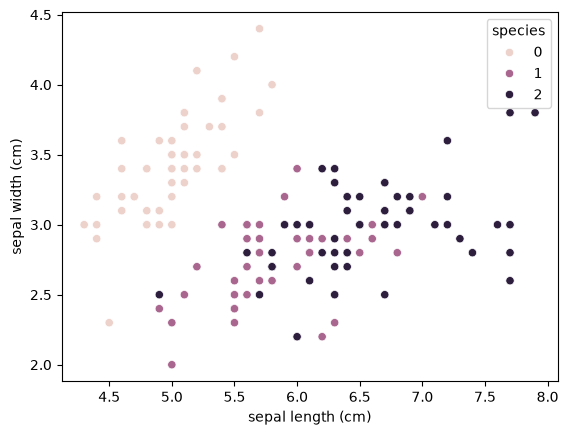

In [38]:
from sklearn.datasets import load_iris

iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["species"] = iris.target

# plot the data as scatterplot
sns.scatterplot(x="sepal length (cm)", y="sepal width (cm)", hue="species", data=df)

In [39]:
df.shape

(150, 5)

In [40]:
# split the data into x and y
X = df.drop("species", axis=1)
y = df["species"]

# split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [41]:
%%time
# train the decision tree classifier
dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)

# predict the test data
y_pred = dtc.predict(X_test)

print("Decision Tree Classifier Accuracy: ", accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred, average="macro"))
print(recall_score(y_test, y_pred, average="macro"))
print(f1_score(y_test, y_pred, average="macro"))

Decision Tree Classifier Accuracy:  1.0
1.0
1.0
1.0
CPU times: total: 93.8 ms
Wall time: 218 ms


In [42]:
%%time
# train the random forest classifier
rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)

# predict the test data
y_pred = rfc.predict(X_test)

print("Random Forest Classifier Accuracy: ", accuracy_score(y_test, y_pred))
print("Random Forest Classifier Precision: ", precision_score(y_test, y_pred, average="macro"))
print("Random Forest Classifier Recall: ", recall_score(y_test, y_pred, average="macro"))
print("Random Forest Classifier F1-Score: ", f1_score(y_test, y_pred, average="macro"))

Random Forest Classifier Accuracy:  1.0
Random Forest Classifier Precision:  1.0
Random Forest Classifier Recall:  1.0
Random Forest Classifier F1-Score:  1.0
CPU times: total: 375 ms
Wall time: 551 ms


In [43]:
%%time
# train the xgboost model
xgb = GradientBoostingClassifier()
xgb.fit(X_train, y_train)

# predict the test data
y_pred = xgb.predict(X_test)

print("Gradient Boosting Classifier Accuracy: ", accuracy_score(y_test, y_pred))
print("Gradient Boosting Classifier Precision: ", precision_score(y_test, y_pred, average="macro"))
print("Gradient Boosting Classifier Recall: ", recall_score(y_test, y_pred, average="macro"))
print("Gradient Boosting Classifier F1-Score: ", f1_score(y_test, y_pred, average="macro"))

Gradient Boosting Classifier Accuracy:  1.0
Gradient Boosting Classifier Precision:  1.0
Gradient Boosting Classifier Recall:  1.0
Gradient Boosting Classifier F1-Score:  1.0
CPU times: total: 828 ms
Wall time: 1.36 s


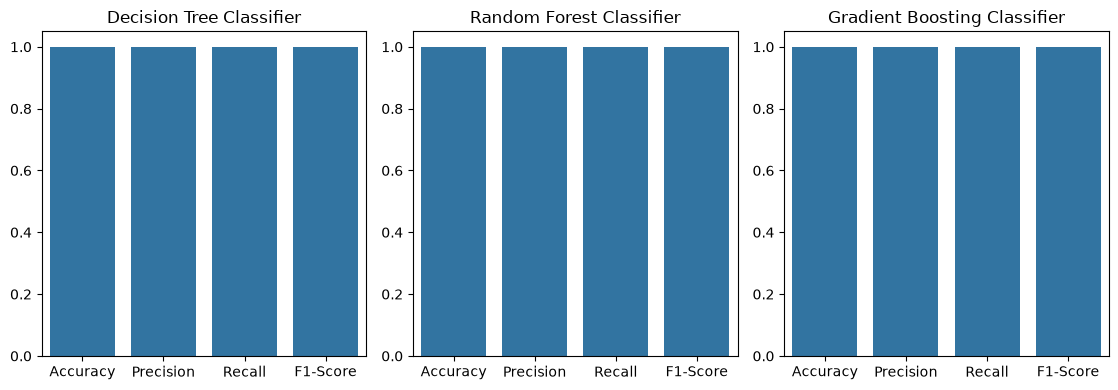

In [44]:
# make a bar plot showing each of the matrix with respect to the model
plt.figure(figsize=(15, 4))
plt.subplot(1, 4, 1)
sns.barplot(x=['Accuracy', 'Precision', 'Recall', 'F1-Score'], y=[accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, average="macro"), recall_score(y_test, y_pred, average="macro"), f1_score(y_test, y_pred, average="macro")])
plt.title('Decision Tree Classifier')
plt.subplot(1, 4, 2)
sns.barplot(x=['Accuracy', 'Precision', 'Recall', 'F1-Score'], y=[accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, average="macro"), recall_score(y_test, y_pred, average="macro"), f1_score(y_test, y_pred, average="macro")])
plt.title('Random Forest Classifier')
plt.subplot(1, 4, 3)
sns.barplot(x=['Accuracy', 'Precision', 'Recall', 'F1-Score'], y=[accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, average="macro"), recall_score(y_test, y_pred, average="macro"), f1_score(y_test, y_pred, average="macro")])
plt.title('Gradient Boosting Classifier')
plt.tight_layout()
plt.show()